In [1]:
import sys
from pathlib import Path

sys.path.append(str(Path().resolve().parent))

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.data_loader import load_data
from src.preprocessing import split_data, build_preprocessor
from src.modeling import build_logistic_regression_pipeline, evaluate_classification_model

In [2]:
df = load_data()

X_train, X_test, y_train, y_test = split_data(df)
preprocessor = build_preprocessor(X_train)

In [3]:
baseline_model = build_logistic_regression_pipeline(preprocessor)

baseline_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

In [4]:
metrics, report, cm = evaluate_classification_model(
    baseline_model, X_train, X_test, y_train, y_test
)

metrics

{'train_accuracy': 0.8945,
 'test_accuracy': 0.881,
 'train_precision': 0.8103448275862069,
 'test_precision': 0.7731958762886598,
 'train_recall': 0.7105831533477321,
 'test_recall': 0.6666666666666666,
 'train_f1': 0.757192174913694,
 'test_f1': 0.7159904534606205,
 'train_roc_auc': 0.9268103834712091,
 'test_roc_auc': 0.9081003584229391}

In [ ]:
# Threshold tuning
y_proba = baseline_model.predict_proba(X_test)[:, 1]

threshold = 0.4
y_pred_custom = (y_proba >= threshold).astype(int)

from sklearn.metrics import classification_report
print(f"Threshold = {threshold}")
print(classification_report(y_test, y_pred_custom))

In [5]:
pd.DataFrame([metrics]).T.rename(columns={0: "value"})

,value
train_accuracy,0.894500
test_accuracy,0.881000
train_precision,0.810345
test_precision,0.773196
train_recall,0.710583
test_recall,0.666667
train_f1,0.757192
test_f1,0.715990
train_roc_auc,0.926810
test_roc_auc,0.908100


In [ ]:
print(report)

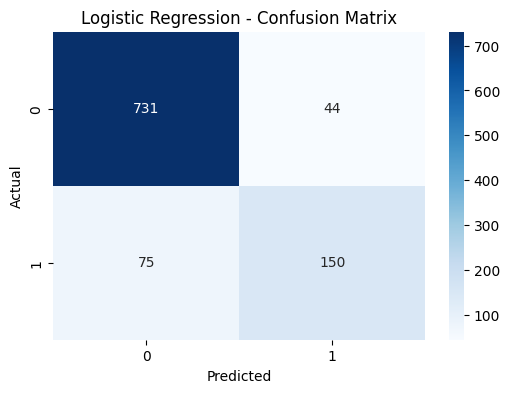

In [6]:
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Logistic Regression - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [7]:
from sklearn.metrics import roc_curve


def get_roc_curve_data(model, X_test, y_test):
    y_proba = model.predict_proba(X_test)[:, 1]
    fpr, tpr, thresholds = roc_curve(y_test, y_proba)
    return fpr, tpr

In [8]:
feature_names = baseline_model.named_steps["preprocessor"].get_feature_names_out()
coefficients = baseline_model.named_steps["classifier"].coef_[0]

coef_df = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coefficients
}).sort_values(by="coefficient", ascending=False)

coef_df.head(10)

,feature,coefficient
3,num__CreditScore,2.119487
16,cat__EmploymentType_Self-Employed,1.340494
15,cat__EmploymentType_Salaried,1.337146
1,num__Income,1.032942
2,num__LoanAmount,0.093007
13,cat__City_New York,0.054688
10,cat__Education_PhD,0.034510
6,cat__Gender_Male,0.017920
4,num__YearsExperience,0.012360
14,cat__City_San Francisco,0.009295


In [9]:
coef_df.head(10)

,feature,coefficient
3,num__CreditScore,2.119487
16,cat__EmploymentType_Self-Employed,1.340494
15,cat__EmploymentType_Salaried,1.337146
1,num__Income,1.032942
2,num__LoanAmount,0.093007
13,cat__City_New York,0.054688
10,cat__Education_PhD,0.034510
6,cat__Gender_Male,0.017920
4,num__YearsExperience,0.012360
14,cat__City_San Francisco,0.009295


In [10]:
coef_df.tail(10)

,feature,coefficient
4,num__YearsExperience,0.012360
14,cat__City_San Francisco,0.009295
8,cat__Education_High School,0.009033
9,cat__Education_Masters,0.004513
5,cat__Gender_Female,-0.014956
12,cat__City_Houston,-0.017146
11,cat__City_Chicago,-0.043872
7,cat__Education_Bachelors,-0.045091
0,num__Age,-0.057490
17,cat__EmploymentType_Unemployed,-2.674675


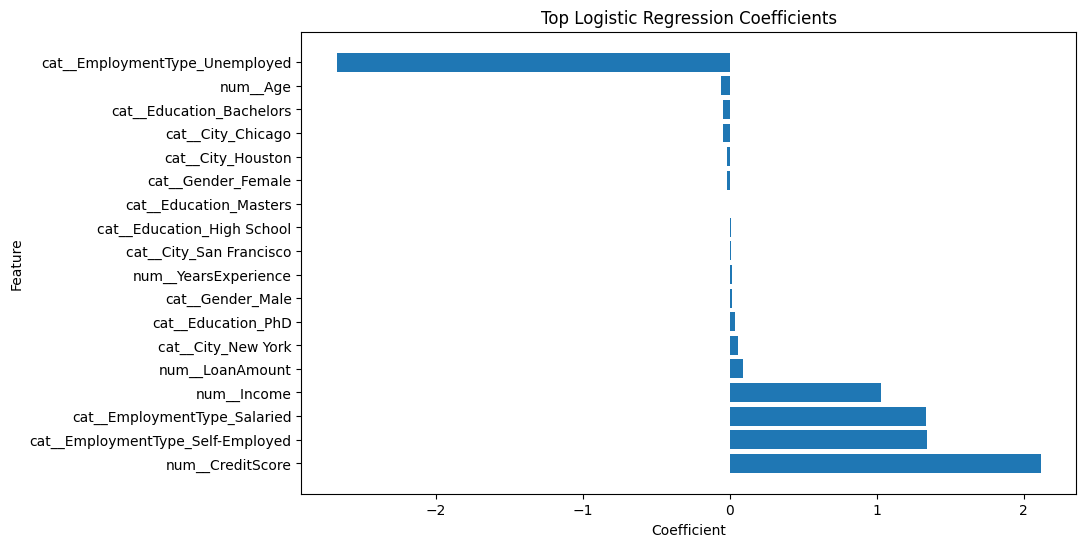

In [11]:
top_positive = coef_df.head(10)
top_negative = coef_df.tail(10)
coef_plot_df = pd.concat([top_positive, top_negative])

plt.figure(figsize=(10, 6))
plt.barh(coef_plot_df["feature"], coef_plot_df["coefficient"])
plt.title("Top Logistic Regression Coefficients")
plt.xlabel("Coefficient")
plt.ylabel("Feature")
plt.show()